# Data Preprocessing and Modeling

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [21]:
# load the cleaned dataset from Notebook 1
df = pd.read_csv("../data/model_df.csv")

In [22]:
# target we want to predict
y = df["Overall_Livability_Score"]

# features used to predict target
X = df.drop(columns=["Overall_Livability_Score"])

In [23]:
# split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

## Baseline Model: Linear Regression

In [24]:
# simple baseline model
model = LinearRegression()

# train model on training data
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
# predict livability scores on test data
y_pred = model.predict(X_test)

In [26]:
# check prediction error
print("MAE:", mean_absolute_error(y_test, y_pred))

# check how well model fits data (0 to 1)
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 3.363771909620338
R2 Score: 0.7121091800860166


<Figure size 800x500 with 0 Axes>

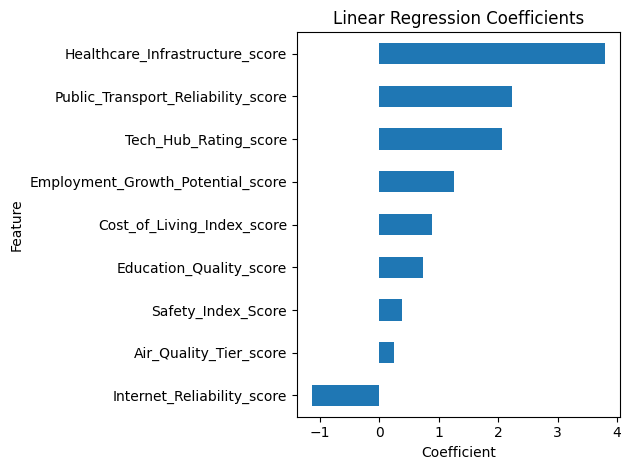

In [29]:
plt.figure(figsize=(8, 5))

coef_df.sort_values("Coefficient").plot(
    x="Feature",
    y="Coefficient",
    kind="barh",
    legend=False
)

plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [30]:
# coefficient summary
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

# magnitude of effect regardless of direction (absolute value)
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

coef_df.sort_values("Abs_Coefficient", ascending=False)

,Feature,Coefficient,Abs_Coefficient
2,Healthcare_Infrastructure_score,3.801996,3.801996
5,Public_Transport_Reliability_score,2.233445,2.233445
7,Tech_Hub_Rating_score,2.073194,2.073194
8,Employment_Growth_Potential_score,1.257708,1.257708
3,Internet_Reliability_score,-1.136239,1.136239
6,Cost_of_Living_Index_score,0.888619,0.888619
4,Education_Quality_score,0.730176,0.730176
0,Safety_Index_Score,0.378638,0.378638
1,Air_Quality_Tier_score,0.241291,0.241291


## Random Forest Model

In [31]:
from sklearn.ensemble import RandomForestRegressor

In [32]:
# create model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# train model
rf.fit(X_train, y_train)

# make predictions
rf_pred = rf.predict(X_test)

In [33]:
print("Random Forest MAE:", mean_absolute_error(y_test, rf_pred))
print("Random Forest R2:", r2_score(y_test, rf_pred))

Random Forest MAE: 3.6774999999999984
Random Forest R2: 0.6623889328063244


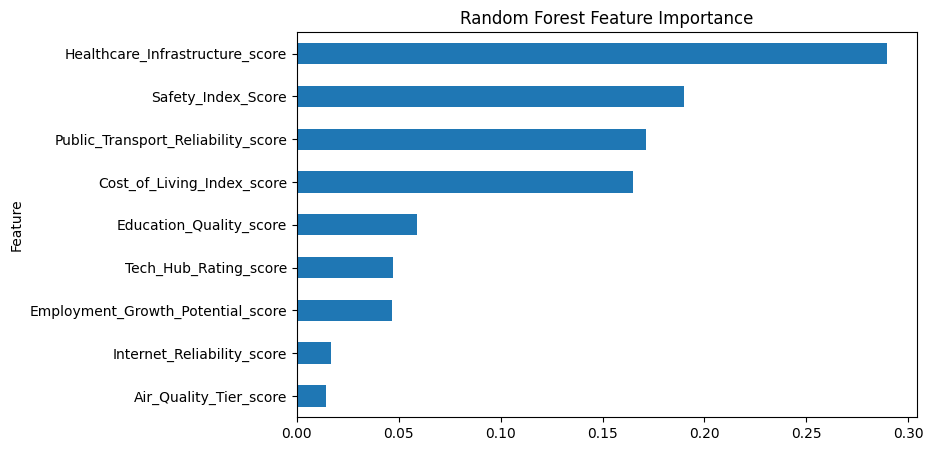

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

rf_importance.sort_values("Importance", ascending=True).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False,
    figsize=(8,5)
)

plt.title("Random Forest Feature Importance")
plt.show()

In [45]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "R2": [
        r2_score(y_test, y_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,MAE,R2
0,Linear Regression,3.363772,0.712109
1,Random Forest,3.677500,0.662389
